In [104]:
import polars as pl
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'svg'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import sklearn.metrics as skm

pl.Config.set_tbl_cols(-1)


polars.config.Config

In [105]:
# importing the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

raw_data = pl.read_csv(url, separator=';', infer_schema_length=10000)

print(raw_data.head(2))

shape: (2, 12)
┌────────┬────────┬────────┬────────┬───────┬───────┬───────┬───────┬──────┬───────┬───────┬───────┐
│ fixed  ┆ volati ┆ citric ┆ residu ┆ chlor ┆ free  ┆ total ┆ densi ┆ pH   ┆ sulph ┆ alcoh ┆ quali │
│ acidit ┆ le aci ┆ acid   ┆ al     ┆ ides  ┆ sulfu ┆ sulfu ┆ ty    ┆ ---  ┆ ates  ┆ ol    ┆ ty    │
│ y      ┆ dity   ┆ ---    ┆ sugar  ┆ ---   ┆ r dio ┆ r dio ┆ ---   ┆ f64  ┆ ---   ┆ ---   ┆ ---   │
│ ---    ┆ ---    ┆ f64    ┆ ---    ┆ f64   ┆ xide  ┆ xide  ┆ f64   ┆      ┆ f64   ┆ f64   ┆ i64   │
│ f64    ┆ f64    ┆        ┆ f64    ┆       ┆ ---   ┆ ---   ┆       ┆      ┆       ┆       ┆       │
│        ┆        ┆        ┆        ┆       ┆ f64   ┆ f64   ┆       ┆      ┆       ┆       ┆       │
╞════════╪════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪══════╪═══════╪═══════╪═══════╡
│ 7.4    ┆ 0.7    ┆ 0.0    ┆ 1.9    ┆ 0.076 ┆ 11.0  ┆ 34.0  ┆ 0.997 ┆ 3.51 ┆ 0.56  ┆ 9.4   ┆ 5     │
│        ┆        ┆        ┆        ┆       ┆       ┆       ┆ 8     ┆      ┆

In [106]:
# remove the spacing in sugar columns
raw_data = raw_data.rename({col : col.replace(" ", "_") for col in raw_data.columns})

In [107]:
# create a new columnn to convert quality to two binaries: 1 for good quality and 0 for bad quality
raw_data = (
    raw_data
    .with_columns(
        new_quality=pl.when(pl.col('quality') > 5)
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
    )
)

In [108]:
# prepare features and labels
features = raw_data.drop('quality', 'new_quality').to_numpy()
labels = raw_data.select('new_quality').to_numpy().squeeze()

# split the data BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=42)

# scale the features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Only transform, don't fit

In [109]:
# convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.int64)
y_test_tensor = torch.tensor(y_test, dtype=torch.int64)


In [110]:
# create dataloaders
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=160)  # Use reasonable batch size

In [111]:
# visualize correlation on scaled training data
train_df = pl.DataFrame(X_train_scaled, schema=raw_data.drop('quality', 'new_quality').columns)
train_df = train_df.with_columns(pl.Series('new_quality', y_train))

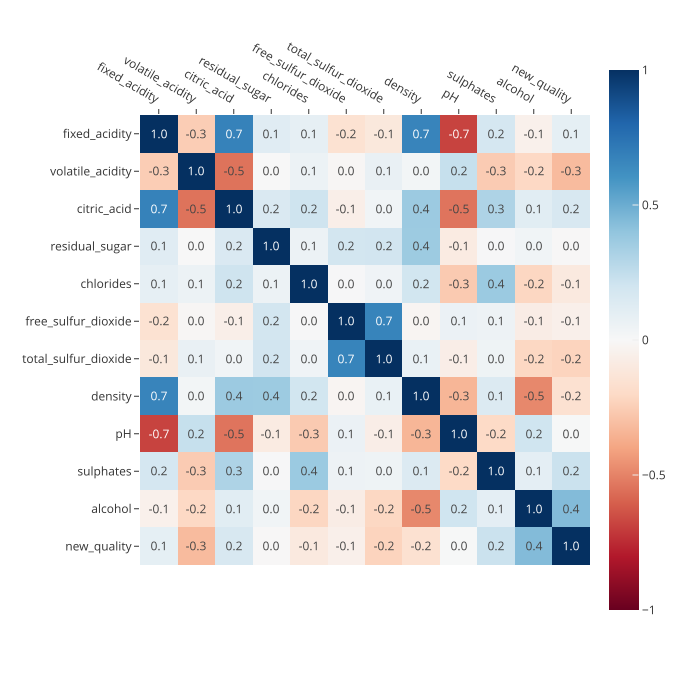

In [112]:
corr_labels = train_df.columns
fig = px.imshow(
    train_df.corr(),
    y=corr_labels,
    text_auto='.1f',
    zmin=-1,
    zmax=1,
    color_continuous_scale='RdBu'
)
fig.update_xaxes(side='top')
fig.update_layout(template='ggplot2', width=700, height=700)
fig.show()

## Create a class for the model & components

In [113]:
class ANNmodel(nn.Module):
    def __init__(self, input_size, nUnits, nLayers):
        super().__init__()

        # create a dictionary to store the layers
        self.layers = nn.ModuleDict()

        # create input layer
        self.layers['input'] = nn.Linear(input_size, nUnits)

        # generate the hidden layers
        for i in range(nLayers):
            self.layers[f'hidden{i}'] = nn.Linear(nUnits, nUnits)

        # output layer (2 classes for binary classification)
        self.layers['output'] = nn.Linear(nUnits, 2)

    def forward(self, x):
        x = F.relu(self.layers['input'](x))
        # hidden layers
        for i in range(len(self.layers) - 2):  # minus input and output layers
            x = F.relu(self.layers[f'hidden{i}'](x))
        # output layer (raw logits)
        x = self.layers['output'](x)
        return x

In [114]:
# create model component
def createANNnet(input_size, nUnits, nLayers, learningRate=0.01):
    model = ANNmodel(input_size, nUnits, nLayers)
    # Use CrossEntropyLoss for binary classification with class indices
    lossfunc = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)
    # Use per-epoch learning rate decay
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.95)

    return model, lossfunc, optimizer, scheduler

In [115]:
# define a function for training
def trainModel(train_loader, test_loader, input_size,nUnits, nLayers, numepochs=500, toggleDynamic=False):
  training_progress = pl.DataFrame(
      schema=[
          ('iteration', pl.Int64),
          ('epoch', pl.Int64),
          ('train_loss', pl.Float64),
          ('train_acc', pl.Float64),
          ('test_loss', pl.Float64),
          ('test_acc', pl.Float64),
          ('learning_rate', pl.Float64)
      ]
  )
  iteration = 0

  # create the ann model
  model, lossfunc, optimizer, scheduler = createANNnet(input_size, nUnits, nLayers)

  # early stopping parameters
  patience = 15
  best_loss = float('inf')
  no_improve_count = 0
  best_model = None

  # training loop
  for epoch in range(numepochs):
    model.train()
    ## create performance metrics to add
    epoch_train_loss = 0
    epoch_train_acc = 0
    num_batches = 0
    ## iterate through the training batches
    for X_trainTL, y_trainTL in train_loader:
      yhat_train = model(X_trainTL)
      train_loss = lossfunc(yhat_train, y_trainTL)
      ### backpropagation
      optimizer.zero_grad()
      train_loss.backward()
      optimizer.step()
      ### evaluate training accuracy
      train_matches = (torch.argmax(yhat_train, axis=1) == y_trainTL).float()
      train_acc = 100 * torch.mean(train_matches)
      ### sum the loss and accuracy
      epoch_train_loss += train_loss.item()
      epoch_train_acc += train_acc.item()
      num_batches += 1
    ## update the learning rate after all batches (once per epoch) - lr decay - if enabled
    if toggleDynamic:
      scheduler.step()
      current_lrs = scheduler.get_last_lr()[0]
    else:
      current_lrs = optimizer.param_groups[0]['lr']

    ## evaluate test set
    model.eval()
    ##
    test_loss_total = 0
    test_acc_total = 0
    test_batches = 0
    with torch.no_grad():
      for X_testTL, y_testTL in test_loader:
        yhat_test = model(X_testTL)
        test_loss = lossfunc(yhat_test.squeeze(), y_testTL)
        ### get the test accuracy
        test_matches = (torch.argmax(yhat_test, axis=1) == y_testTL).float()
        test_acc = 100 * torch.mean(test_matches)

        test_loss_total += test_loss.item()
        test_acc_total += test_acc.item()
        test_batches += 1
    # average test metrics
    avg_test_loss = test_loss_total / test_batches
    avg_test_acc = test_acc_total / test_batches


    ## log a single row per epoch and append the new row to training dataframe
    new_row = pl.DataFrame([{
        'iteration': iteration,
        'epoch': epoch,
        'train_loss': epoch_train_loss / num_batches,
        'train_acc': epoch_train_acc / num_batches,
        'test_loss': avg_test_loss,
        'test_acc': avg_test_acc,
        'learning_rate': current_lrs
    }])
    training_progress = training_progress.vstack(new_row)
    iteration += 1

    ## early stopping if there is no further improvement to the model
    """starts with infinity so any real loss will be smaller.
    When the model improves, it means test_loss is less than best loss, thus the counter rests and it is being saved as the best model"""
    if avg_test_loss < best_loss:
      best_loss = avg_test_loss # update the best loss when the model improves
      no_improve_count = 0 # reset the counter to 0
      best_model = copy.deepcopy(model)
    else:
      no_improve_count += 1
      if no_improve_count >= patience:
        print(f'Stopping at {epoch + 1} - No improvements for {patience} epochs')
        break

    ## print out performance after every 20 epochs
    if epoch % 20 == 0 or epoch == numepochs - 1:
       print(
          f"Epoch {epoch+1}/{numepochs} - "
          f"Training: Loss={epoch_train_loss / num_batches:.4f}, "
          f"Accuracy={epoch_train_acc / num_batches:.2f}% | "
          f"Testing: Loss={avg_test_loss:.4f}, "
          f"Accuracy={avg_test_acc:.2f}% | "
          f"Learning Rate: {current_lrs:.6f}"
       )

  # return both training model progress and best model
  return training_progress, best_model if best_model is not None else model


In [116]:
# quickly test if the loop is working
training_progress, trained_model = trainModel(train_loader=train_loader, test_loader=test_loader, input_size=11, nUnits=64, nLayers=2, numepochs=500, toggleDynamic=False)

Epoch 1/500 - Training: Loss=0.5785, Accuracy=70.03% | Testing: Loss=0.5443, Accuracy=78.75% | Learning Rate: 0.010000
Epoch 21/500 - Training: Loss=0.3621, Accuracy=83.24% | Testing: Loss=0.4706, Accuracy=78.12% | Learning Rate: 0.010000
Stopping at 31 - No improvements for 15 epochs


## Compute the performance matrix

In [117]:
# predictins for the training data
train_predictions = trained_model(train_loader.dataset.tensors[0])
train_predictions_class = torch.argmax(train_predictions, dim=1)
print("Training predictions shape:", train_predictions.shape)
print("Training predictions (first 10):", train_predictions_class[:10])

Training predictions shape: torch.Size([1439, 2])
Training predictions (first 10): tensor([1, 1, 1, 0, 0, 1, 1, 0, 0, 0])


In [118]:
# prediction for the test data
test_predictions = trained_model(test_loader.dataset.tensors[0])
test_predictions_class = torch.argmax(test_predictions, dim=1)
print("Test predictions shape:", test_predictions.shape)
print("Test predictions (first 10):", test_predictions_class[:10])

Test predictions shape: torch.Size([160, 2])
Test predictions (first 10): tensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 1])


In [119]:
# Calculate metrics (same as before)
train_metrics = [0,0,0,0]
test_metrics  = [0,0,0,0]

train_metrics[0] = skm.accuracy_score(train_loader.dataset.tensors[1], train_predictions_class)
train_metrics[1] = skm.precision_score(train_loader.dataset.tensors[1], train_predictions_class)
train_metrics[2] = skm.recall_score(train_loader.dataset.tensors[1], train_predictions_class)
train_metrics[3] = skm.f1_score(train_loader.dataset.tensors[1], train_predictions_class)

test_metrics[0] = skm.accuracy_score(test_loader.dataset.tensors[1], test_predictions_class)
test_metrics[1] = skm.precision_score(test_loader.dataset.tensors[1], test_predictions_class)
test_metrics[2] = skm.recall_score(test_loader.dataset.tensors[1], test_predictions_class)
test_metrics[3] = skm.f1_score(test_loader.dataset.tensors[1], test_predictions_class)

In [120]:
metrics_df = pl.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'] * 2,
    'Score': train_metrics + test_metrics,
    'Dataset': ['Train'] * 4 + ['Test'] * 4
})

print(metrics_df)

shape: (8, 3)
┌───────────┬──────────┬─────────┐
│ Metric    ┆ Score    ┆ Dataset │
│ ---       ┆ ---      ┆ ---     │
│ str       ┆ f64      ┆ str     │
╞═══════════╪══════════╪═════════╡
│ Accuracy  ┆ 0.842946 ┆ Train   │
│ Precision ┆ 0.850843 ┆ Train   │
│ Recall    ┆ 0.85528  ┆ Train   │
│ F1-score  ┆ 0.853056 ┆ Train   │
│ Accuracy  ┆ 0.825    ┆ Test    │
│ Precision ┆ 0.840909 ┆ Test    │
│ Recall    ┆ 0.840909 ┆ Test    │
│ F1-score  ┆ 0.840909 ┆ Test    │
└───────────┴──────────┴─────────┘


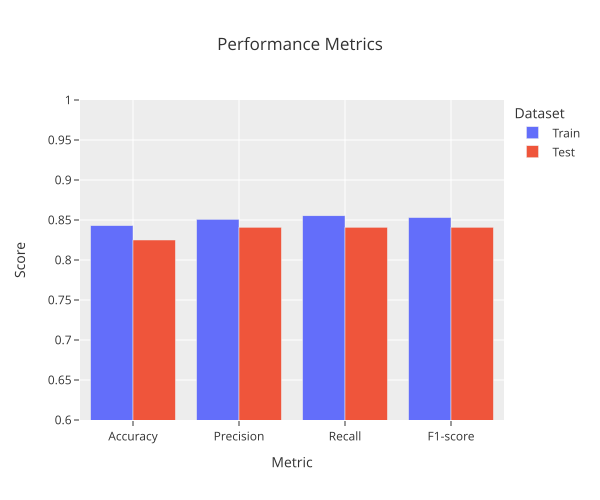

In [121]:
fig = px.bar(metrics_df, x='Metric', y='Score', color='Dataset',
             title='Performance Metrics', barmode='group',
             range_y=[0.6, 1.0])

fig.update_layout(template='ggplot2', width=600)
fig.show()

In [122]:
# confusion matrix
trainConf = skm.confusion_matrix(train_loader.dataset.tensors[1], train_predictions_class)
testConf = skm.confusion_matrix(test_loader.dataset.tensors[1], test_predictions_class)

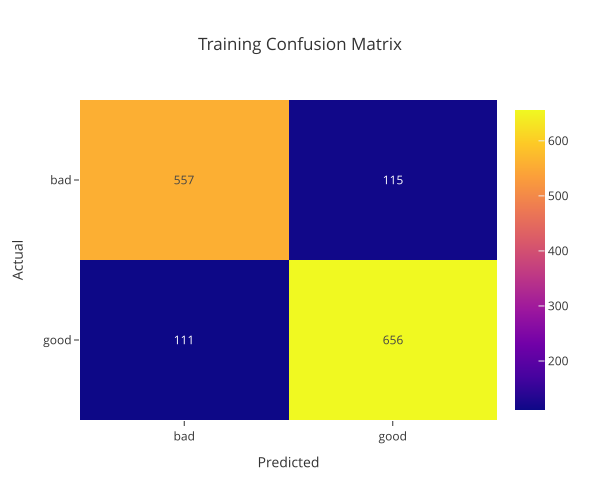

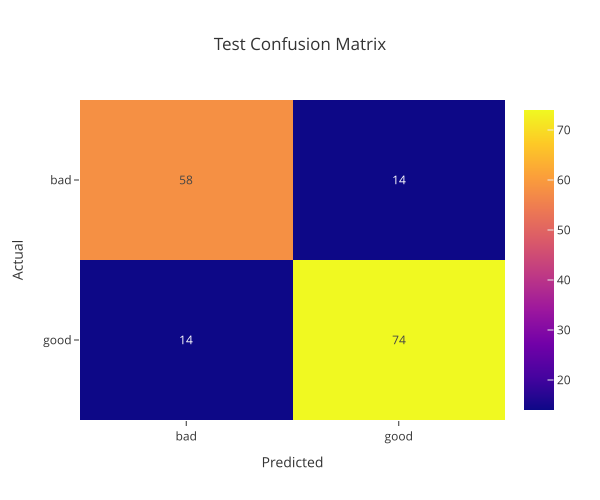

In [123]:
# Training confusion matrix
fig_train = px.imshow(trainConf, text_auto=True, aspect="auto",
                      title="Training Confusion Matrix",
                      labels={'x': 'Predicted', 'y': 'Actual'},
                      x=['bad', 'good'], y=['bad', 'good'])
fig_train.update_layout(template='ggplot2', width=600)
fig_train.show()

# Test confusion matrix
fig_test = px.imshow(testConf, text_auto=True, aspect="auto",
                     title="Test Confusion Matrix",
                     labels={'x': 'Predicted', 'y': 'Actual'},
                     x=['bad', 'good'], y=['bad', 'good'])
fig_test.update_layout(template='ggplot2', width=600)
fig_test.show()

In [125]:
# recommendations from claude AI
print("Training metrics:")
print(f"  Accuracy:  {train_metrics[0]:.4f}")
print(f"  Precision: {train_metrics[1]:.4f}")
print(f"  Recall:    {train_metrics[2]:.4f}")
print(f"  F1-score:  {train_metrics[3]:.4f}")

print("\nTest metrics:")
print(f"  Accuracy:  {test_metrics[0]:.4f}")
print(f"  Precision: {test_metrics[1]:.4f}")
print(f"  Recall:    {test_metrics[2]:.4f}")
print(f"  F1-score:  {test_metrics[3]:.4f}")

# Detailed breakdown
print("\nDetailed breakdown:")
print("=" * 40)
print(f"Training accuracy: {train_metrics[0]:.1%}")
print(f"Test accuracy: {test_metrics[0]:.1%}")
print(f"Difference: {abs(train_metrics[0] - test_metrics[0]):.1%}")

if abs(train_metrics[0] - test_metrics[0]) > 0.05:
    print("⚠️  Large gap between train and test accuracy - possible overfitting")
else:
    print("✅ Good generalization - small gap between train and test accuracy")

Training metrics:
  Accuracy:  0.8429
  Precision: 0.8508
  Recall:    0.8553
  F1-score:  0.8531

Test metrics:
  Accuracy:  0.8250
  Precision: 0.8409
  Recall:    0.8409
  F1-score:  0.8409

Detailed breakdown:
Training accuracy: 84.3%
Test accuracy: 82.5%
Difference: 1.8%
✅ Good generalization - small gap between train and test accuracy


### Interpretation
* the idea scenario is:
    * high precision: when the model calls 'good wine', it is correct
        * high precision =  conservative bias (reluctant to call 'good wine')
        * low precision = liberal bias (too eager to call 'good wine')
    * high recall: it finds most of the correct 'good wine'
    * High F1-score: Good balance between the two metrics
* unlike medical diagnosis, it is preferbly to prioritize precision because we want it to be good at 'picking' 'good wines' in this case
    * for medical diagnosis, we want it to prioritize recall because we do not want it to misscall a diseases